In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import numpy as np
from astropy.table import Table
from astropy.io import ascii
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay
import pandas as pd
from itertools import combinations
import networkx as nx
from sklearn.decomposition import PCA
import matplotlib.cm as cm
import itertools
from scipy.spatial import cKDTree

In [3]:
filt_n1 = Table.read("/content/drive/MyDrive/DESI/data/LRG_NGC_data_filt1.ecsv").to_pandas()

In [12]:
n_random = 10
rand_ngc1 = {}
for i in range(n_random):
    rand_ngc1[i] = Table.read(f"/content/drive/MyDrive/DESI/rand/LRG_NGC_1_random_{i}_filt.fits").to_pandas()
    rand_ngc1[i]['type'] = 'rand'

In [5]:
void = {}
for j in range(1):
        file = f"/content/drive/MyDrive/DESI/connections_groups/LRG_NGC_1_random_{j}_neighbors_void.parquet"
        df = pd.read_parquet(file)
        void[j] = df

In [6]:
filament = {}
for j in range(1):
        file = f"/content/drive/MyDrive/DESI/connections_groups/LRG_NGC_1_random_{j}_neighbors_filament.parquet"
        df = pd.read_parquet(file)
        filament[j] = df

In [7]:
knot = {}
for j in range(1):
        file = f"/content/drive/MyDrive/DESI/connections_groups/LRG_NGC_1_random_{j}_neighbors_knot.parquet"
        df = pd.read_parquet(file)
        knot[j] = df

In [45]:
def identify_fof_groups(data, group, linking_length=50):
    id_group = zip(group['TARGETID'],group['TARGETID_filament'])

    targetid_filaments = group['TARGETID_filament'].unique()
    data = data[data['TARGETID'].isin(targetid_filaments)].copy()

    #Aplicar Friends-of-Friends (FoF) con KDTree
    positions = data[['x', 'y', 'z']].values
    tree = cKDTree(positions)
    pairs = tree.query_pairs(r=linking_length)

    #Construir grupos (componentes conexas)
    parent = list(range(len(positions)))

    def find(i):
        while parent[i] != i:
            parent[i] = parent[parent[i]]
            i = parent[i]
        return i

    def union(i, j):
        ri, rj = find(i), find(j)
        if ri != rj:
            parent[ri] = rj

    for i, j in pairs:
        union(i, j)

    group_ids = np.array([find(i) for i in range(len(positions))])
    _, group_ids = np.unique(group_ids, return_inverse=True)
    data['group_id'] = group_ids

    return data

In [105]:
def plot_top_n_groups(df, n=3, point_size=0.01):

    # obtain the N groups with the most points
    top_ids = df['group_id'].value_counts().head(n).index.tolist()

    colors = plt.cm.tab20(np.linspace(0, 1, n))

    plt.figure(figsize=(12, 10))
    for group_id, color in zip(top_ids, colors):
        subset = df[df['group_id'] == group_id]
        plt.scatter(subset['x_rot'], subset['y_rot'], s=point_size, label=f'Group {group_id}')

    plt.xlabel("X [Mpc]", fontsize=14)
    plt.ylabel("Y [Mpc]", fontsize=14)
    plt.title(f"Top {n} Groups with Most Points - Filaments",fontsize=15)
    #plt.legend(fontsize=8)
    #plt.grid(True)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.tight_layout()
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()

In [106]:
def alignment(df):
    if hasattr(df, 'to_pandas'):
        df = df.to_pandas()
    coords = df[['x', 'y', 'z']].values.astype(float)
    pca = PCA(n_components=3)
    coords_rotated = pca.fit_transform(coords)
    return coords_rotated

In [107]:
def new_coords(data):
    new_coords = alignment(data)
    data[['x_rot', 'y_rot', 'z_rot']] = new_coords

## Linking_length = 21

In [108]:
%%time
df_filament_groups = identify_fof_groups(filt_n1, filament[0], linking_length=21)

CPU times: user 5.63 s, sys: 260 ms, total: 5.89 s
Wall time: 6.25 s


In [109]:
print('Number groups: ',len(set(df_filament_groups['group_id'])))

Number groups:  24742


In [110]:
new_coords(df_filament_groups)

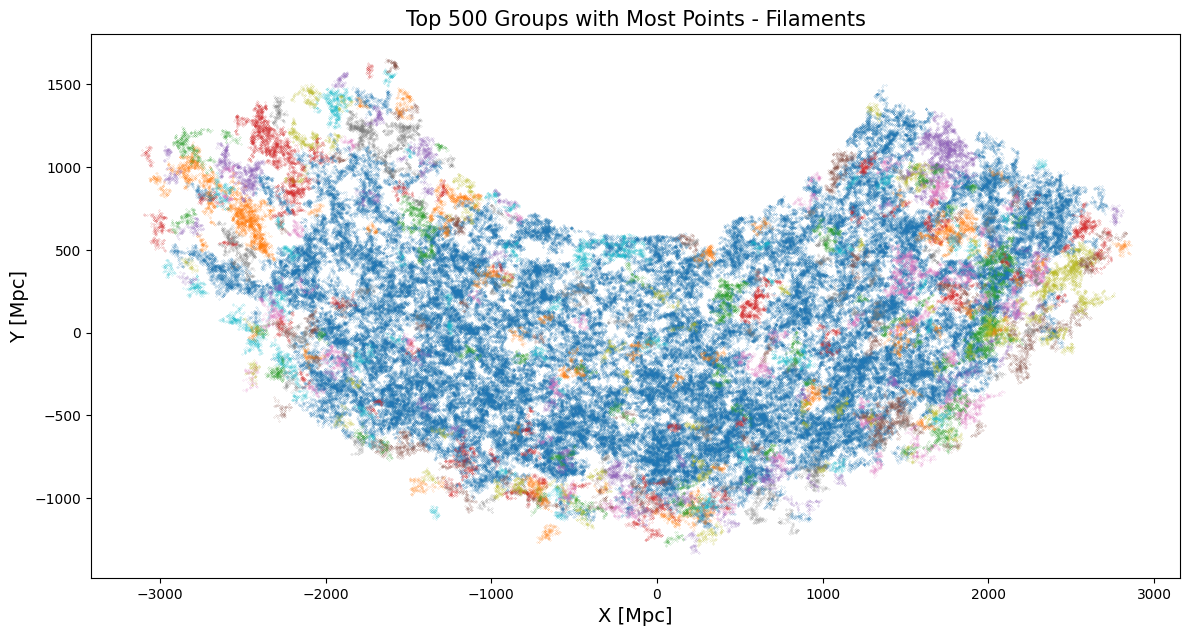

In [111]:
plot_top_n_groups(df_filament_groups, n=500)

## Linking_length = 20

In [112]:
%%time
df_filament_groups = identify_fof_groups(filt_n1, filament[0], linking_length=20)

CPU times: user 4.93 s, sys: 157 ms, total: 5.09 s
Wall time: 5.08 s


In [113]:
new_coords(df_filament_groups)

In [114]:
print('Number groups: ',len(set(df_filament_groups['group_id'])))

Number groups:  29287


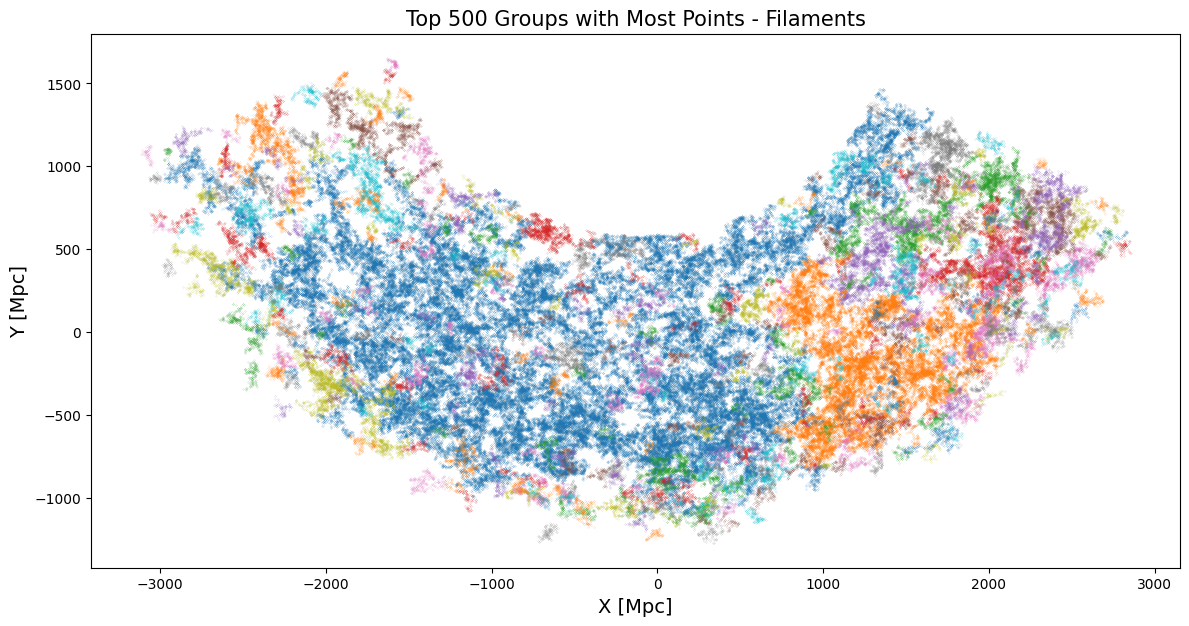

In [115]:
plot_top_n_groups(df_filament_groups, n=500)